## COMP47670 Assignment 2
### Juhi Anand(19200134)


## INTRODUCTION:
This assignment is about scraping reviews from a website and evaluting the thr performance of text classification algorithm on the data. The notebook below consists of three main sections:

> 1.<b> DATA COLLECTION</b> : In this section we are creating datasets by scraping three categories of reviews and storing them for further evaluation. A discussion has also been made on the state of tha datasets scaped. 

> 2.<b> TEXT PRE-PROCESSING, CLASSIFICATION AND EVALUATION</b>: In this section we are pre-processing the reviews/text using standard text analytics approach. Then we are first evaluating the performance of three classifiers on one category of review and finally testing and evaluating the best model from first step on other two set of categories. 

> 3.<b> TRAINING MODEL WITH ONE CATEGORY AND TESTING ON OTHER TWO CATEGORIES</b> : Using the same best performing model from section two, we train the model on the entire dataset of 1 category and test/evaluate the models performance on the other two set of categories. We repeat this process three time so that each time the model is trained with a new category and the other two categories are used to test the model.


In [1]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
from nltk.corpus import stopwords 
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

#  <B><center>PART1: DATA COLLECTION</center></B>

## Task1: Web Scrapping
> First we define a variable that holds the link of the website from which data has to be fetched:http://mlg.ucd.ie/modules/yalp/

> Then two functions are defined:<b> getWebPageData()</b> and <b>scrapeWebPageData()</b>. First one retrieves the response from the given URL and the sceond one using BeautifulSoup scrapes all the links from the response. 


In [2]:
##Variable url hold the link to the website from which reviews are to be scrapped
url="http://mlg.ucd.ie/modules/yalp/"

In [3]:
##Function to fetch data using the url
def getWebPageData(link):
    response=requests.get(link)
    return response

In [4]:
##Function to scrape the different yalp categories from the web-page
def scrapeWebPageData(webText):
    soup = BeautifulSoup(webText, 'html')
    urls = []
    for heading in soup.find_all('a', href=True):
        if heading.text:
            urls.append(heading['href'])
    urls.pop(0)
    return urls


In [5]:
## Call the getWebPageData function to extract data from the website
result=getWebPageData(url)
txt=result.text

## Call the getCategories function to scrape different review categories from the website
categoryUrls=scrapeWebPageData(txt)
categoryUrls #Links for all the sub categories

['automotive_list.html',
 'cafes_list.html',
 'fashion_list.html',
 'gym_list.html',
 'hair_salons_list.html',
 'hotels_list.html',
 'restaurants_list.html']

## Task2: Selecting Three Categories
> The URL return five review categorie. As directed ,below we fetch reviews URL for three of these categories: <b>Fashion, Gym and Salon</b>. The categories have been choosen such them all of them relate to each other, as each of them might have some text common as three of them are reviews related to physical appearance in some manner.

In [6]:
## Below from list of review categories, select 3 categories of choice and get data/reviews for the three categories
reviewCategoryList = []
choiceList=['fashion_list.html','gym_list.html','hair_salons_list.html']
for category in choiceList: 
    categoryResponse = getWebPageData(url+category) ##get data for a particular category
    categoryData=categoryResponse.text
    reviewCategoryList.append(scrapeWebPageData(categoryData)) #get review id
#reviewCategoryList

## Task 3: Creating and storing datasets
> After the review URLs for each category has been fetched, we we will fetch review and rating for each URL.(The review URLs for each category is stored in the array reviewCategory list which holds three elements like below Snippet:)
![image.png](attachment:image.png)

> We parse the response using BeautifulSoup. First we look for review-text tags to fetch the review text and the tag img to fetch the rating given with that particular review. The rating has data like '1-Star', if the number at first position is less than four then it's a negative review, else positive.


> The reviews and their rating  for each category is then stored in a dataframe. <b> createDF </b>function has been written to scrape the reviews from the above extracted URLs and to create dataframe to for each of the category. Initially, these dataframes consist of two columns: 
1. Review: holds the unprocessed review text
2. Rating holds the review sentiment(positive/negative)


In [7]:
def createDF(reviewCategoryList):   
    
    review = []
    rating = []
    for reviewURL in reviewCategoryList:
        response =getWebPageData(url+reviewURL)
        webData= BeautifulSoup(response.text, 'html')
        for data in webData.findAll('p', class_ ="review-text"):
            review.append(data.text)
        for ratings in webData.findAll('img'): #ratings is present in image tag
            #print(ratings.get('alt'))
            if ratings.get('alt') != None: #fetch when rating is present
                if int(ratings.get('alt')[0]) < 4: #ratings have text like 1-star, so fetch 0th index of the String and compare
                    rating.append('Negative')
                else:
                    rating.append('Positive')
                            
    reviewDF = pd.DataFrame(list(zip(review, rating)),columns =['Review', 'Rating'],index=None) #create new dataframe
    return reviewDF

### Create Fashion Dataset
> Create dataset and store it into fashion.csv

In [8]:
fashion = createDF(reviewCategoryList[0])
fashion.to_csv("fashion.csv",index=False)
fashion.head(5)

,Review,Rating
0,Looking for the best tactical supplies? Look n...,Positive
1,Stood in line like an idiot for 5 minutes to p...,Negative
2,Another great store with quality Equipment. Th...,Positive
3,The Problem with this store is not that they h...,Positive
4,Great place! We went in at almost closing time...,Positive


### Create Gym Dataset
> Create dataset and store it into gym.csv

In [9]:
gym = createDF(reviewCategoryList[1])
gym.to_csv("gym.csv",index=False)
gym.head(5)

,Review,Rating
0,If you're looking for boxing in the East Valle...,Positive
1,I was really excited to try a fun workout rout...,Negative
2,I was interested in taking a boxing bootcamp c...,Negative
3,I worked out at 1 on 1 boxing for a bout 6 mon...,Positive
4,This place literally KICKED my butt every. sin...,Positive


### Create Salon Dataset
> Create dataset and store it into salon.csv

In [10]:
salon = createDF(reviewCategoryList[2])
salon.to_csv("salon.csv",index=False)
salon.head(5)

,Review,Rating
0,"One of the best barbershops I've been to, with...",Positive
1,Took my son in for a haircut. Barber was great...,Positive
2,"Walked in, said hi. The only barber in there d...",Negative
3,I came here 10 minutes before 9am to get a hai...,Negative
4,"Great haircut. No fuss no muss, I asked for la...",Positive


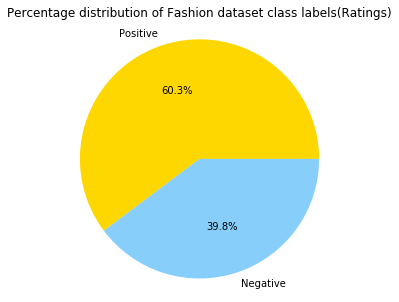

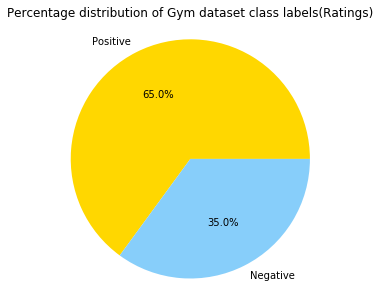

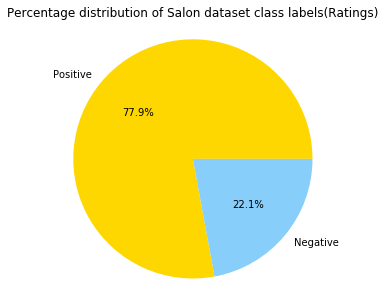

In [11]:
# Pie chart: Fashion
plt.subplots(figsize=(5,5))
plt.pie(fashion.Rating.value_counts(),labels=['Positive','Negative'],autopct='%.1f%%',radius=1.1,colors = ['gold', 'lightskyblue'])
plt.title('Percentage distribution of Fashion dataset class labels(Ratings)')

# Pie chart: Gym
plt.subplots(figsize=(5,5))
plt.pie(gym.Rating.value_counts(),labels=['Positive','Negative'],autopct='%.1f%%',radius=1.1,colors = ['gold', 'lightskyblue'])
plt.title('Percentage distribution of Gym dataset class labels(Ratings)')


# Pie chart: Salon
plt.subplots(figsize=(5,5))
plt.pie(salon.Rating.value_counts(),labels=['Positive','Negative'],autopct='%.1f%%',radius=1.1,colors = ['gold', 'lightskyblue'])
plt.title('Percentage distribution of Salon dataset class labels(Ratings)')
plt.show()

##  <font color='green'>Conclusion: </font>
> From the above plots we can deduce that the data for all the three datasets is not completeley balanced. There are more positive reviews than the negative ones for all the datasets. This dataset could be made balanced by using different sampling techniques, however this is not the scope of this project hence we will focus on using the right evaluation metrics to evalute the models performance on this data. 

### Read all the three csv files and create new dataframes, on which further processing can be applied

In [12]:
fashionDF=pd.read_csv('fashion.csv')
gymDF=pd.read_csv('gym.csv')
salonDF=pd.read_csv('salon.csv')
print(fashionDF.shape)
print(gymDF.shape)
print(salonDF.shape)

(2000, 2)
,(2000, 2)
,(2000, 2)


#  <B><center>PART2: TEXT PRE-PROCESSING, CLASSIFICATION AND EVALUATION</center></B>


## Task1: Text Preproccesing
Insetead of using sckit-learns default properties, following altternate pre-processing steps have been performed to process the collected data before creating a document term matrix and applying it to the classification models:

> - <b>Tokenisation:</b> Reviews have been stored as raw text, not numeric. The first step is to split the raw text into individual tokens, each corresponding to a single term (word).
> - <b>Case Conversion</b> used lower() function to convert all the text to lower, if not handled explicitly
> - <b>Stop-word Removal:</b> We then remove all the terms which are highly frequent and convey less useful information (stop_words="english") as these words add no value to the text.
> - <b>Lemmatization with POS Tagging: </b> used NLTKs WordNetLemmatizer  to perform lemmatisation on each token to reduce them to base forms. Lemmatization has been done with POS tagging
> - <b>Low frequency filtering:</b> Remove terms that appear less than 5 times in all the reviews. (min_df = 5)
> - <b>Minimum term length: </b> Exclude terms of length < 2. Done by Default in Scikit-learn.
> - <b>Normalisation: </b> The most common normalisation used term frequency–inverse document frequency (TF-IDF)

###############################################################################################################
> <b>tokenize():</b> This function below use RegexpTokenizer to create tokens for each review.

> <b>remove_stopwords():</b> By Using NLTK stopwords vocabulary,all the stopwords included in this module have been removed.

><b>get_wordnet_pos():</b>Uses NLTKs wordnet and pos_tag() to attach appropriate parts of speech to each token so that all the words are reduced to correct base forms.

> <b>lemmatize():</b> This function uses NLTK wordnet lemmatiser with tags from get_wordnet_pos() to reduce all the words to their base forms. (lemmatization with POS Tagging takes a bit more execution time than usual)


In [13]:
#Defining a Functions that will Convert to lower case, tokenize, remove stopwords and lemmatize the raw text
tokenizer = RegexpTokenizer(r'\w+')
def tokenize(x): 
       return tokenizer.tokenize(x.lower())

def remove_stopwords(word_tokens):
    filtered_sentence = [] 
    stop_words = set(stopwords.words('english'))
    for w in word_tokens: 
        if w not in stop_words: 
            filtered_sentence.append(w) 
    return filtered_sentence

def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize(x):
    lemmatizer = WordNetLemmatizer()
    return' '.join([lemmatizer.lemmatize(word,get_wordnet_pos(word)) for word in x])

# Just a preliminary data processing step to check if any null values exist in any of the datasets:
print("Checking Null Values for Fashion DF:")
print(fashionDF.isna().sum())
print("Checking Null Values for Gym DF:")
print(gymDF.isna().sum())
print("Checking Null Values for Salon DF:")
print(salonDF.isna().sum())

Checking Null Values for Fashion DF:
,Review    0
,Rating    0
,dtype: int64
,Checking Null Values for Gym DF:
,Review    0
,Rating    0
,dtype: int64
,Checking Null Values for Salon DF:
,Review    0
,Rating    0
,dtype: int64


> <b>In the next three cells we are applying pre-processting steps to each of the datasets and after preprocessing, each processed review is added to the corresponding fieldof the new column 'Processed_Review', in each of the dataset.
Moving forward, text in 'Processed_Review'  and Rating fields will be used train and test the model.</b>

In [14]:
fashionDF['Processed_Review']=""
fashionDF['Processed_Review']=fashionDF['Review'].map(tokenize)
fashionDF['Processed_Review']=fashionDF['Processed_Review'].map(remove_stopwords)
fashionDF['Processed_Review']=fashionDF['Processed_Review'].map(lemmatize)
fashionDF.head(5)

,Review,Rating,Processed_Review
0,Looking for the best tactical supplies? Look n...,Positive,look best tactical supply look ma police emt m...
1,Stood in line like an idiot for 5 minutes to p...,Negative,stood line like idiot 5 minute purchase 2 pant...
2,Another great store with quality Equipment. Th...,Positive,another great store quality equipment staff su...
3,The Problem with this store is not that they h...,Positive,problem store awesome customer service entire ...
4,Great place! We went in at almost closing time...,Positive,great place go almost closing time feel rush p...


In [15]:
gymDF['Processed_Review']=""
gymDF['Processed_Review']=gymDF['Review'].map(tokenize)
gymDF['Processed_Review']=gymDF['Processed_Review'].map(remove_stopwords)
gymDF['Processed_Review']=gymDF['Processed_Review'].map(lemmatize)
gymDF.head(5)

,Review,Rating,Processed_Review
0,If you're looking for boxing in the East Valle...,Positive,look boxing east valley highly recommend gym o...
1,I was really excited to try a fun workout rout...,Negative,really excite try fun workout routine would al...
2,I was interested in taking a boxing bootcamp c...,Negative,interested take boxing bootcamp class research...
3,I worked out at 1 on 1 boxing for a bout 6 mon...,Positive,work 1 1 boxing bout 6 month love pricing reas...
4,This place literally KICKED my butt every. sin...,Positive,place literally kick butt every single time ac...


In [16]:
salonDF['Processed_Review']=""
salonDF['Processed_Review']=salonDF['Review'].map(tokenize)
salonDF['Processed_Review']=salonDF['Processed_Review'].map(remove_stopwords)
salonDF['Processed_Review']=salonDF['Processed_Review'].map(lemmatize)
salonDF.head(5)

,Review,Rating,Processed_Review
0,"One of the best barbershops I've been to, with...",Positive,one best barbershop great price honestly happi...
1,Took my son in for a haircut. Barber was great...,Positive,take son haircut barber great exactly want cle...
2,"Walked in, said hi. The only barber in there d...",Negative,walk say hi barber courtesy say hi back busy w...
3,I came here 10 minutes before 9am to get a hai...,Negative,come 10 minute 9am get haircut open 9am saturd...
4,"Great haircut. No fuss no muss, I asked for la...",Positive,great haircut fuss mus ask layer v shape back ...


## Task2 & Task3 : Creating Document-Term Matrix, Classification & Evaluation
<b> <font color='red'> <i>NOTE:</i> Creating term-document matrix is also a pre-processing step but has been performed here after splitting the test and train data so that we don't use test data to fit the vectoriser. </font> </b>

> Train/Test Split: split the dataset into a training set and a test set into 70:30 ratio, respectively. Also, to achieve same results for every run, random_state is set to be an integer.

> Sckit-Learn TfidfVectorizer has been used to create a document term matrix, in this approach higher weight is given to more important terms, unlike CountVectoriser which just counts the number of occurrences of each word. 

> We will initially classify data using the three classsifiers: RandomForest, Naive-Bayes, LogisticRegression. After evaluating the performance results of all the three models using some metrics, we will proceed with the model selected for further classifications.


In [17]:
#Create train, test splits for all three dataframes
XFashionTrain, XFashionTest, yFashionTrain, yFashionTest = train_test_split(fashionDF['Processed_Review'], fashionDF['Rating'], test_size=0.3,random_state = 123)
XGymTrain, XGymTest, yGymTrain, yGymTest = train_test_split(gymDF['Processed_Review'], gymDF['Rating'], test_size=0.3,random_state = 123)
XSalonTrain, XSalonTest, ySalonTrain, ySalonTest = train_test_split(salonDF['Processed_Review'], salonDF['Rating'], test_size=0.3,random_state = 123)
print(XFashionTrain.shape,yFashionTrain.shape)
print(XGymTrain.shape,yGymTrain.shape)
print(XSalonTrain.shape,ySalonTrain.shape)

(1400,) (1400,)
,(1400,) (1400,)
,(1400,) (1400,)


In [18]:
#Building the vectorizer
#vectorizer = TfidfVectorizer(min_df = 5) #max_features=1500
vectorizer = TfidfVectorizer()

#Define the three classifier models
rfmodel = RandomForestClassifier(n_estimators = 100, random_state=123) #RandomForestClassifier
clfmodel = MultinomialNB() #Naive-Bayes Classifier
lrmodel = LogisticRegression( solver='lbfgs') #Logistic Regression Classifier

### To make code more modular, created below function for repeating tasks.
>  <b>plotConfusionmatrix:</b> contains code to print an elobarate informative confusion-matrix as a heatmap

In [19]:
def plotConfusionmatrix(cf_matrix):
    fig, ax = plt.subplots(figsize=(5,5))
    group_names = ['True Neg','False Pos','False Neg','True Pos']
    categories = ['Negative','Positive']
    group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='OrRd',xticklabels=categories,yticklabels=categories)

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title("Confusion Matrix",fontsize=10)
    plt.rcParams.update({'font.size': 12})
    ax.set_ylim([0,2])
    plt.show()

### Classification Model for Fashion Category
> For evaluation purpose, only for Fashion category we are using all the three classification models

In [20]:
# Transform the train and the test data
#Using the pandas dataframe displaying a Document Term Matrix by converting the tfidf matrix to array and transforming it.
XFashionTrainTrans= vectorizer.fit_transform(XFashionTrain)
XFashionTestTrans = vectorizer.transform(XFashionTest)

#Train the model using all the three classifiers
rfmodel.fit(XFashionTrainTrans, yFashionTrain)
clfmodel.fit(XFashionTrainTrans, yFashionTrain)
lrmodel.fit(XFashionTrainTrans, yFashionTrain)

#Do the predction on test data using the classifiers
yFashionPred=rfmodel.predict(XFashionTestTrans)
yFashionClfPred=clfmodel.predict(XFashionTestTrans)
yFashionLRPred=lrmodel.predict(XFashionTestTrans)

### Model Evaluation for Fashion Category
In general, we will be using following metrics to evaluate our models, choice of metrics influences how the performance of machine learning algorithms is measured and compared :

> 1. <b>Cross Validation:</b> Using default scoring method of cross_val_score() we will perform 4 fold cross validation on the training dataset.

> 2. <b>Hold-Out Testing Accuracy Score:</b> Accuracy score calculated is the number of correct predictions made by the model over all kinds predictions made.( However, since this is an imbalanced dataset this score might not be correct metric to evalute models performance.)

> 3. <b>Confusion Matrix:</b> It is a table showing correct predictions and types of incorrect predictions. It gives values for True Positive, True Negative, False Positives and False Negatives, predictions made by the classifier, which could be utilised to evaluate the different performance metrics. For our example we are prediction whether the review is 'Positive' or 'Negative'. The labels of the confusion matrix would indicate following:<b><br><br>
   - <font color='red'>TP:</font> Case where the actual review is positive and the classifier also predicts it as positive.
   - <font color='red'>TN:</font> Case where the actual review is negative and the classifier also predicts it as negative.
   - <font color='red'>FP:</font> Case where the actual review is negative but the classifier predicts it as positive.
   - <font color='red'>FN:</font> Case where the actual review is positive but the classifier predicts it as negative.</b>

> 4. <b>Classification_report:</b> Detailed classification report is also calculated, which gives detailed information about the Precision, Recall, f1 score which could also be calculated using metrics derived from the confusion metrics.


<h3>Below we are evaluating the three models on the basis of accuracy and ROC-AUC metrics.</h3>

> 1. <b>First Graph</b>: displays the accuracy score calculated through cross validation on training data and hold-out testing on test data.

> 2. <b>Second Graph:</b> displays ROC-AUC curve/score calculated using Scikit-Learns roc_curve and roc_auc_score.

In [21]:
#Created three lists below, which will used to create a dataframe which will hold performace data for different models.
trainDataAccuracy = []
testDataAccuracy = []
model_name = ['Random-Forest','Naive-Bayes', 'Log-Regression' ]

##Cross Validation : Accuracy from the training using Cross Validation for:
#RandomForest classifier
scores = cross_val_score(rfmodel, XFashionTrainTrans, yFashionTrain, cv=4 )
trainDataAccuracy.append(scores.mean())
#Naive-Bayes classifier
scores = cross_val_score(clfmodel, XFashionTrainTrans, yFashionTrain, cv=4)
trainDataAccuracy.append(scores.mean())
#LogisticRegression classifier
scores = cross_val_score(lrmodel, XFashionTrainTrans, yFashionTrain, cv=4)
trainDataAccuracy.append(scores.mean())


##Hold-out testing: Accuracy on test data using Hold-Out Testing for:
#RandomForest classifier
score=accuracy_score(yFashionTest,yFashionPred)
testDataAccuracy.append(score)
#Naive-Bayes classifier
score=accuracy_score(yFashionTest,yFashionClfPred)
testDataAccuracy.append(score)
#LogisticRegression classifier
score=accuracy_score(yFashionTest,yFashionLRPred)
testDataAccuracy.append(score)

accuracyDF = pd.DataFrame()

accuracyDF['Model_Type'] = model_name
accuracyDF['Train_Accuracy'] = trainDataAccuracy
accuracyDF['Test_Accuracy'] = testDataAccuracy

accuracyDF.head()

,Model_Type,Train_Accuracy,Test_Accuracy
0,Random-Forest,0.838571,0.860000
1,Naive-Bayes,0.795000,0.793333
2,Log-Regression,0.855000,0.875000


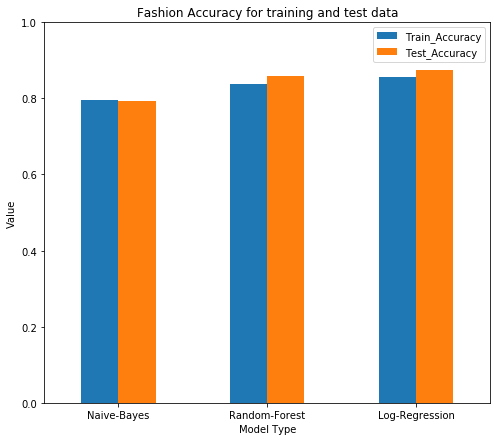

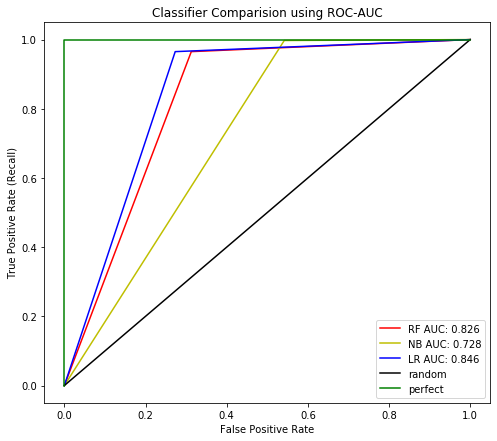

In [22]:
accuracyDF = accuracyDF.sort_values(["Train_Accuracy", "Test_Accuracy"], ascending=[True, True])
ax = accuracyDF.plot(figsize=(8,7),kind='bar',x="Model_Type", rot=0,y=["Train_Accuracy", "Test_Accuracy"],yticks=[0, 0.2, 0.4,0.6,0.8, 1],sort_columns='y', title="Fashion Accuracy for training and test data")
ax.set_ylabel("Value")
ax.set_xlabel("Model Type")

#ROC Calculation
y = np.array([(1 if i=='Positive' else 0) for i in yFashionTest.tolist()])
FashionPred= np.array([(1 if i=='Positive' else 0) for i in yFashionPred.tolist()])
FashionClfPred=np.array([(1 if i=='Positive' else 0) for i in yFashionClfPred.tolist()])
FashionLRPred=np.array([(1 if i=='Positive' else 0) for i in yFashionLRPred.tolist()])
fpr_RF, tpr_RF, thresholds_RF = roc_curve(y, FashionPred,pos_label=1)
fpr_NB, tpr_NB, thresholds_NB = roc_curve(y, FashionClfPred,pos_label=1)
fpr_LR, tpr_LR, thresholds_LR = roc_curve(y, FashionLRPred,pos_label=1)

#AUC CAlculation
auc_RF = roc_auc_score(y, FashionPred)
auc_NB = roc_auc_score(y, FashionClfPred)
auc_LR = roc_auc_score(y, FashionLRPred)

###ROC PLOT
plt.subplots(figsize=(8,7))
plt.plot(fpr_RF, tpr_RF,'r-',label = 'RF AUC: %.3f'%auc_RF)
plt.plot(fpr_NB, tpr_NB,'y-',label = 'NB AUC: %.3f'%auc_NB)
plt.plot(fpr_LR,tpr_LR,'b-', label= 'LR AUC: %.3f'%auc_LR)
plt.plot([0,1],[0,1],'k-',label='random')
plt.plot([0,0,1,1],[0,1,1,1],'g-',label='perfect')
plt.legend()
plt.title("Classifier Comparision using ROC-AUC")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.show()

[NOTE: Conclusions on above graphs is discussed below]

### Further Evaluation for  Fashion Category using Logistic regression classifier


,##################################################################################
,Confusion matrix
,##################################################################################
,
, Confusion matrix for Random Forest Model:


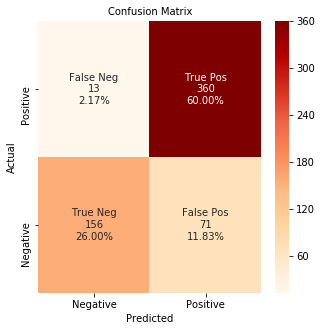


,Confusion matrix for Naive-Bayes Model:


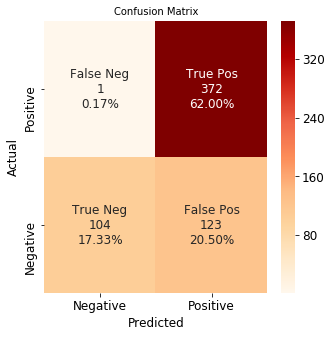


,Confusion matrix for Logistic Regression Model:


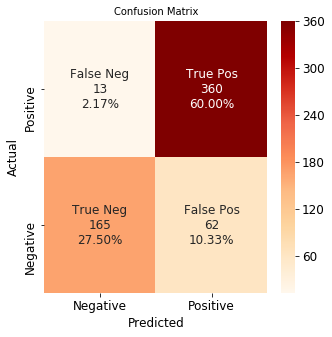

##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
,Positive  percentage in Fashion set : 0.38
,Predicted Negative percentage for Fashion Set for RF MODEL: 0.28
,Predicted Negative percentage for Fashion Set for NAIVE BAYES MODEL: 0.18
,Predicted Negative percentage for Fashion Set for LR MODEL: 0.30
,
,##################################################################################
,Classification Report for LR Model
,##################################################################################
,              precision    recall  f1-score   support
,
,    Positive       0.93      0.73      0.81       227
,    Negative       0.85      0.97      0.91       373
,
,    accuracy                           0.88       600
,   macro avg       0.89      0.85      0.86       600
,weighted avg      

In [23]:
print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################")
cf_matrix = confusion_matrix(yFashionTest,yFashionPred)
print("\n Confusion matrix for Random Forest Model:")
plotConfusionmatrix(cf_matrix)

cf_matrix = confusion_matrix(yFashionTest,yFashionClfPred)
print("\nConfusion matrix for Naive-Bayes Model:")
plotConfusionmatrix(cf_matrix)

cf_matrix = confusion_matrix(yFashionTest, yFashionLRPred)
print("\nConfusion matrix for Logistic Regression Model:")
plotConfusionmatrix(cf_matrix)

print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")
yFashionReplaced= yFashionTest.replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
yFashionPredReplaced= pd.Series(yFashionPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
yFashionPredClfReplaced= pd.Series(yFashionClfPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
yFashionPredLRReplaced= pd.Series(yFashionLRPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
print("Positive  percentage in Fashion set : %0.2f" % (1- (yFashionReplaced.sum()/len(yFashionReplaced))))
print("Predicted Negative percentage for Fashion Set for RF MODEL: %0.2f" % (1- (yFashionPredReplaced.sum()/len(yFashionPredReplaced))))
print("Predicted Negative percentage for Fashion Set for NAIVE BAYES MODEL: %0.2f" % (1- (yFashionPredClfReplaced.sum()/len(yFashionPredClfReplaced))))
print("Predicted Negative percentage for Fashion Set for LR MODEL: %0.2f" % (1- (yFashionPredLRReplaced.sum()/len(yFashionPredLRReplaced))))

print("\n##################################################################################")
print("Classification Report for LR Model")
print("##################################################################################")
print(classification_report(yFashionTest, yFashionLRPred, target_names=gymDF['Rating'].unique()))

##  <font color='green'>Conclusion: </font>

#### WHY LOGISTIC REGRESSION MODEL?
![image.png](attachment:image.png)
- From the above image we can see all the three models give comparitively good accuracy on the the test data. However, if we see <b>the ROC-AUC score Logistic Regresstion model has a accuracy score more towards 1 (0.84 for LR Model, 0.82 for Random Forest and 0.72 for Naive Bayes), i.e more towards the perfect curve.</b> Greater the value of AUC, better is the performance of the model. Hence, decided to proceed with the L-R Model. Also, there seems to be no over-fitting. 

- There are around 38% of Negative reviews in the actual fashion dataset which was used to test the model and out of all the three <b>Logistic Regression Model predicted highest (30%) number of negative reviews</b>.

- Also, all the three classifiers have high number of True positives, however number of <b>False positive for LR Model is compaatively less.</b> In our example FP should be as least as possible because for the long run, these business cannot afford false reviews because if they are not performing well, they should know it so as they make improvements to their services.
    However, some FN could be allowed, because if the review is positive and the classifier predicts it as negative, the owners would still be trying to improve their services and customer experience and this would help in increasing the business.Lastly, since in this case we are focusing on low False Positives as possible, we would look for a model with high precision score.
 

### Classification Model and Evaluation for Gym Category

In [24]:
XGymTrainTrans= vectorizer.fit_transform(XGymTrain)
XGymTestTrans = vectorizer.transform(XGymTest)
lrmodel.fit(XGymTrainTrans, yGymTrain)
yGymPred = lrmodel.predict(XGymTestTrans)

##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
, Negative percentage in Gym set : 0.33
,Predicted Negative  percentagefor Gym Set: 0.29
,
,##################################################################################
,Cross Validation : Accuracy from the training using Cross Validation
,##################################################################################
,
,4x CV_AUC on Training Data: 0.96
,
,##################################################################################
,Hold-out testing on test data
,##################################################################################
,Hold-out Accuracy on Test Data: 0.90
,
,##################################################################################
,Classification Report
,#########################################

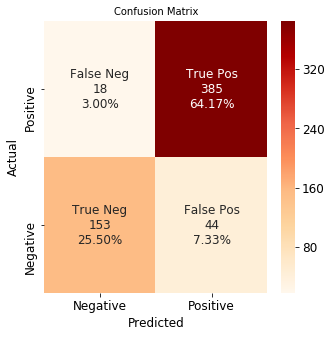

In [25]:
print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")
#Replacing positive by 1 and Negative by 0
yGymReplaced= yGymTest.replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
yGymPredReplaced= pd.Series(yGymPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
print(" Negative percentage in Gym set : %0.2f" % (1- (yGymReplaced.sum()/len(yGymReplaced))))
print("Predicted Negative  percentagefor Gym Set: %0.2f" % (1- (yGymPredReplaced.sum()/len(yGymPredReplaced))))


print("\n##################################################################################")
print("Cross Validation : Accuracy from the training using Cross Validation")
print("##################################################################################") 
scores = cross_val_score(lrmodel, XGymTrainTrans, yGymTrain, cv=4,scoring= 'roc_auc' )
print("\n4x CV_AUC on Training Data: {0:.2f}".format(scores.mean()))

print("\n##################################################################################")
print("Hold-out testing on test data")
print("##################################################################################")
print("Hold-out Accuracy on Test Data: {0:.2f}".format(accuracy_score(yGymTest,yGymPred)))

print("\n##################################################################################")
print("Classification Report")
print("##################################################################################")
print(classification_report(yGymTest, yGymPred, target_names=gymDF['Rating'].unique()))

print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################") 
cf_matrix = confusion_matrix(yGymTest, yGymPred)
plotConfusionmatrix(cf_matrix)


## <font color='green'>Conclusion: </font>
There were 33% Negative reviews in the actual Gym dataset and the model predicted arorund 29%, which is not bad.
From the above evaluation results, we can see the LR model's accuray (for category GYM)on the training data is 96% and that on test data is 90%, which is not very bad. However, the number of false positives is also quite less for the Gym category as compared to the Fashion Category, with Logistic regression model. The percentage of False positives for model trained with gym data is almost less than 3% to that of fashion. And, as expected precision score is also good.



###  Classification Model and Evaluation for Salon Category

In [26]:
XSalonTrainTrans= vectorizer.fit_transform(XSalonTrain)
XSalonTestTrans = vectorizer.transform(XSalonTest)

lrmodel.fit(XSalonTrainTrans, ySalonTrain)
ySalonPred = lrmodel.predict(XSalonTestTrans)

##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
,Negative percentage in Salon set : 0.20
,Predicted Negative percentage for Salon Set: 0.10
,
,##################################################################################
,Cross Validation : Accuracy from the training using Cross Validation
,##################################################################################
,4x CV_AUC on Training Data: 0.98
,
,##################################################################################
,Hold-out testing on test data
,##################################################################################
,Hold-out Accuracy on Test Data: 0.90
,
,##################################################################################
,Classification Report
,########################################

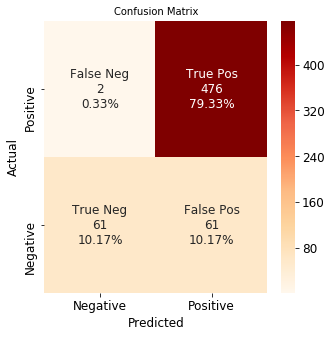

In [27]:
print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")
#Replacing positive by 1 and Negative by 0
ySalonReplaced= ySalonTest.replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
ySalonPredReplaced= pd.Series(ySalonPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])

print("Negative percentage in Salon set : %0.2f" % (1- (ySalonReplaced.sum()/len(ySalonReplaced))))
print("Predicted Negative percentage for Salon Set: %0.2f" % (1- (ySalonPredReplaced.sum()/len(ySalonPredReplaced))))

print("\n##################################################################################")
print("Cross Validation : Accuracy from the training using Cross Validation")
print("##################################################################################")
scores = cross_val_score(lrmodel, XSalonTrainTrans, ySalonTrain, cv=4,scoring= 'roc_auc' )
print("4x CV_AUC on Training Data: {0:.2f}".format(scores.mean()))

print("\n##################################################################################")
print("Hold-out testing on test data")
print("##################################################################################")
print("Hold-out Accuracy on Test Data: {0:.2f}".format(accuracy_score(ySalonTest,ySalonPred)))


print("\n##################################################################################")
print("Classification Report")
print("##################################################################################")
print(classification_report(ySalonTest, ySalonPred, target_names=salonDF['Rating'].unique()))

print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################")
cf_matrix = confusion_matrix(ySalonTest, ySalonPred)
plotConfusionmatrix(cf_matrix)


## <font color='green'>Conclusion: </font>
There were 20% Negative reviews in the actual Salon dataset and the model predicted only 10% of them.
For both the categories Gym and Salon the performance of the logistic regression model is quite good. For both training and test data, both the models seem to have around 90% of accuracy. The number of FP is more less in case of the Gym and number of FN in case of Salon is comparatively lower. And, we definitely want low FP and FN for our models.But as stated above,lower FPs is more preferred for this scenario.
Taking number of false positives in account, individual models, tend to perform good on the Gym Dataset.

#  <B><center>PART3: TRAINING MODEL WITH ONE CATEGORY AND TESTING ON OTHER TWO CATEGORIES</center></B>
<b> <font color='red'> <i>NOTE:</i> Conclusion for all the three classifications have been discussed together at last </font> </b>

> 1) First we store the target labels for each category in panda series. We then create another set of series which have 1 for positive and 0 for negative, from the series created at the first step. This has been done to calculate and compare the percentage of each target labels that exist in actual test set VS percentage of each target labels in the predicted set.

> 2) <b>fit_trans():</b> This function takes three dataframes as input. The first parameter is the category which which is use to fit the vectoriser, because it is the train data with which we will fit the  classification model. The other two categories are the data which once transformed using the same fitted vectoriser, will be used to test the classification model.  Specifically, we don't want to fit the TFIDFVectorizer on the entire corpus, otherwise it will give the model hints(leakage) about what features may be in the test set that don't exist in the training set.

In [28]:
#Fetch and store all theh target labels
yFashion =fashionDF['Rating']
yGym= gymDF['Rating']
ySalon= salonDF['Rating'] 

#Replacing positive by 1 and Negative by 0
yFashionReplaced= yFashion.replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
yGymReplaced= yGym.replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
ySalonReplaced= ySalon.replace(to_replace = ['Positive', 'Negative'], value = [1, 0])

In [29]:
def fit_trans(category1DF, category2DF, category3DF):
    vectorizer = TfidfVectorizer(max_features=1500, min_df=5)
    vector= vectorizer.fit(category1DF['Processed_Review'])
    category1TransDF=vector.transform(category1DF['Processed_Review']).toarray()
    category2TransDF=vector.transform(category2DF['Processed_Review']).toarray()
    category3TransDF=vector.transform(category3DF['Processed_Review']).toarray()          
    return category1TransDF, category2TransDF, category3TransDF 

### Train a classification model on the data from “Category A”. Evaluate its performance on data from “Category B” and data from “Category C”.
Train on Fashion datset and test on Gym and Salon datasets


,##################################################################################
,Cross Validation : Accuracy from the training using Cross Validation
,##################################################################################
,
,4x CV_AUC on Fashion Training Data: 0.94
,**************************************** Category Gym**************************************** 
,##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
,Negative in Gym set : 0.35
,Predicted Negative for Gym Set: 0.27
,
,##################################################################################
,Hold-out testing on test data
,##################################################################################
,Hold-out Accuracy on Test Data: 0.88
,
,###################################################################

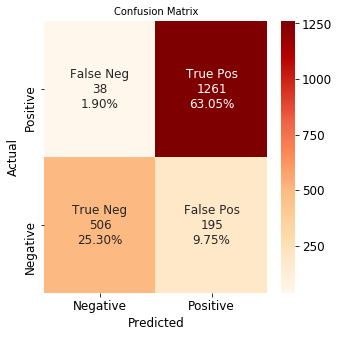

**************************************** Category Salon ****************************************
,##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
,Negative in Salon set : 0.22
,Predicted Negative for Salon Set: 0.18
,
,##################################################################################
,Hold-out testing on test data
,##################################################################################
,Hold-out Accuracy on Test Data: 0.92
,
,##################################################################################
,Classification Report
,##################################################################################
,              precision    recall  f1-score   support
,
,    Positive       0.88      0.73      0.80       442
,    Negative       0.93      0.97      0.9

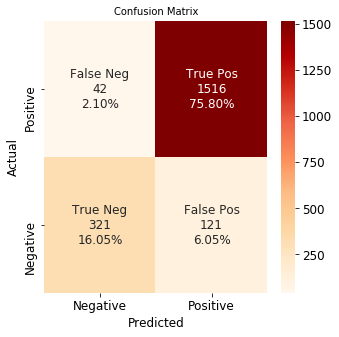

In [30]:
#Fit the vectoriser and transform the data
fashionTransDF,gymTransDF, salonTransDF= fit_trans(fashionDF,gymDF,salonDF)
#Train the model
lrmodel.fit(fashionTransDF, yFashion)

#predict on category Fashion
yGymPred = lrmodel.predict(gymTransDF)
#predict on category Salon
ySalonPred = lrmodel.predict(salonTransDF)

train_acc_pred=[]
test_acc1_pred=[]
test_acc2_pred=[]

print("\n##################################################################################")
print("Cross Validation : Accuracy from the training using Cross Validation")
print("##################################################################################")
scores = cross_val_score(lrmodel, fashionTransDF, yFashion, cv=4,scoring= 'roc_auc' )
print("\n4x CV_AUC on Fashion Training Data: {0:.2f}".format(scores.mean()))
train_acc_pred.append(round(scores.mean(),3))
################################################################################################
#Evaluation on category Gym
print("**************************************** Category Gym**************************************** ")

print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")
yGymPredReplaced= pd.Series(yGymPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])
print("Negative in Gym set : %0.2f" % (1- (yGymReplaced.sum()/len(yGymReplaced))))
print("Predicted Negative for Gym Set: %0.2f" % (1- (yGymPredReplaced.sum()/len(yGymPredReplaced))))

print("\n##################################################################################")
print("Hold-out testing on test data")
print("##################################################################################")
print("Hold-out Accuracy on Test Data: {0:.2f}".format(accuracy_score(yGym,yGymPred)))
test_acc1_pred.append(round(accuracy_score(yGym,yGymPred),3))
print("\n##################################################################################")
print("Classification Report")
print("##################################################################################")
print(classification_report(yGym, yGymPred, target_names=yGym.unique()))

print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################")
cf_matrix = confusion_matrix(yGym, yGymPred)
plotConfusionmatrix(cf_matrix)


#############################################################################################
#Evaluation on category Salon
print("**************************************** Category Salon ****************************************")

print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")
ySalonPredReplaced= pd.Series(ySalonPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])

print("Negative in Salon set : %0.2f" % (1- (ySalonReplaced.sum()/len(ySalonReplaced))))
print("Predicted Negative for Salon Set: %0.2f" % (1- (ySalonPredReplaced.sum()/len(ySalonPredReplaced))))

print("\n##################################################################################")
print("Hold-out testing on test data")
print("##################################################################################")
print("Hold-out Accuracy on Test Data: {0:.2f}".format(accuracy_score(ySalon,ySalonPred)))
test_acc2_pred.append(round(accuracy_score(ySalon,ySalonPred),3))

print("\n##################################################################################")
print("Classification Report")
print("##################################################################################")
print(classification_report(ySalon, ySalonPred, target_names=ySalon.unique()))

print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################")
cf_matrix = confusion_matrix(ySalon, ySalonPred)
plotConfusionmatrix(cf_matrix)


### <b>b.Train a classification model on the data from “Category B”. Evaluate its performance on data from “Category A” and data from “Category C”.</b>
Train on Gym datset and test on Fashion and Salon datasets


,##################################################################################
,Cross Validation : Accuracy from the training using Cross Validation
,##################################################################################
,
,4x CV_AUC on Gym Training Data: 0.96
,**************************************** Category Fashion****************************************
,##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
,Negative in Fashion set : 0.40
,Predicted Negative for Fashion Set: 0.36
,
,##################################################################################
,Hold-out testing on test data
,##################################################################################
,Hold-out Accuracy on Test Data: 0.86
,
,############################################################

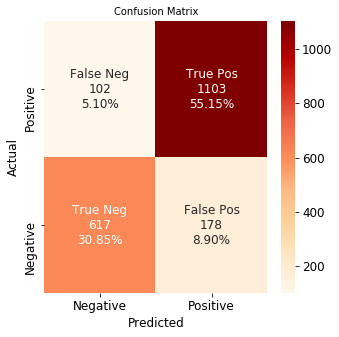

**************************************** Category Salon****************************************
,##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
,Negative in Salon set : 0.22
,Predicted Negative for Salon Set: 0.23
,
,##################################################################################
,Hold-out testing on test data
,##################################################################################
,Accuracy on Test Data: 0.92
,
,##################################################################################
,Classification Report
,##################################################################################
,              precision    recall  f1-score   support
,
,    Positive       0.81      0.84      0.83       442
,    Negative       0.95      0.94      0.95      155

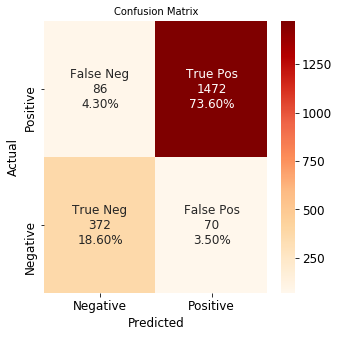

In [31]:
#Fit the vectoriser and transform the data
gymTransDF,fashionTransDF, salonTransDF= fit_trans(gymDF,fashionDF,salonDF)
#Train the model
lrmodel.fit(gymTransDF, yGym)


#predict on category Fashion
yFashionPred = lrmodel.predict(fashionTransDF)
#predict on category salon
ySalonPred = lrmodel.predict(salonTransDF)
print("\n##################################################################################")
print("Cross Validation : Accuracy from the training using Cross Validation")
print("##################################################################################")
scores = cross_val_score(lrmodel, gymTransDF, yGym, cv=4,scoring= 'roc_auc' )
print("\n4x CV_AUC on Gym Training Data: {0:.2f}".format(scores.mean()))
train_acc_pred.append(round(scores.mean(),3))
################################################################################################33
#Evaluation on category Fashion
print("**************************************** Category Fashion****************************************")

print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")
yFashionPredReplaced= pd.Series(yFashionPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])

print("Negative in Fashion set : %0.2f" % (1- (yFashionReplaced.sum()/len(yFashionReplaced))))
print("Predicted Negative for Fashion Set: %0.2f" % (1- (yFashionPredReplaced.sum()/len(yFashionPredReplaced))))


print("\n##################################################################################")
print("Hold-out testing on test data")
print("##################################################################################")
print("Hold-out Accuracy on Test Data: {0:.2f}".format(accuracy_score(yFashion,yFashionPred)))
test_acc1_pred.append(round(accuracy_score(yFashion,yFashionPred),3))
print("\n##################################################################################")
print("Classification Report")
print("##################################################################################")
print(classification_report(yFashion, yFashionPred, target_names=yFashion.unique()))

print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################")  
cf_matrix = confusion_matrix(yFashion, yFashionPred)
plotConfusionmatrix(cf_matrix)



#############################################################################################
#Evaluation on category Salon
print("**************************************** Category Salon****************************************")


print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")
ySalonPredReplaced= pd.Series(ySalonPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])

print("Negative in Salon set : %0.2f" % (1- (ySalonReplaced.sum()/len(ySalonReplaced))))
print("Predicted Negative for Salon Set: %0.2f" % (1- (ySalonPredReplaced.sum()/len(ySalonPredReplaced))))

print("\n##################################################################################")
print("Hold-out testing on test data")
print("##################################################################################")
print("Accuracy on Test Data: {0:.2f}".format(accuracy_score(ySalon,ySalonPred)))
test_acc2_pred.append(round(accuracy_score(ySalon,ySalonPred),3))

print("\n##################################################################################")
print("Classification Report")
print("##################################################################################")
print(classification_report(ySalon, ySalonPred, target_names=ySalon.unique()))

print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################")
cf_matrix = confusion_matrix(ySalon, ySalonPred)
plotConfusionmatrix(cf_matrix)




### <b>c.Train a classification model on the data from “Category C”. Evaluate its performance on data from “Category A” and data from “Category B”.</b>
Train on Salon datset and test on Fashion and Gym datasets.


,##################################################################################
,Cross Validation : Accuracy from the training using Cross Validation
,##################################################################################
,
,4x CV_AUC on Salon Training Data: 0.97
,****************************************  Category Gym **************************************** 
,##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
,Negative in Gym set : 0.35
,Predicted Negative for Gym Set: 0.16
,
,##################################################################################
,Hold-out testing on test data
,##################################################################################
,Hold-out Accuracy on Test Data: 0.80
,
,###################################################################

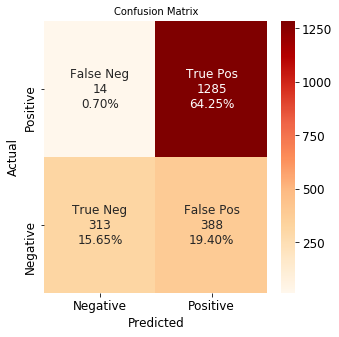

**************************************** Category Fashion ****************************************
,##################################################################################
,Calculating the percentage of each labels that exist Vs the labels predicted
,##################################################################################
,Negative in Fashion set : 0.40
,Predicted Negative for Fashion Set: 0.21
,
,##################################################################################
,Hold-out testing on test data
,##################################################################################
,Accuracy on Test Data: 0.79
,
,##################################################################################
,Classification Report
,##################################################################################
,              precision    recall  f1-score   support
,
,    Positive       0.96      0.50      0.66       795
,    Negative       0.75      0.99      0.85  

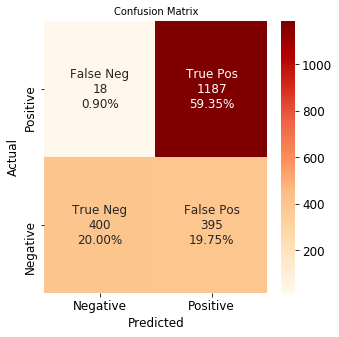

In [32]:
#Fit the vectoriser and transform the data
salonTransDF,gymTransDF, fashionTransDF= fit_trans(salonDF,gymDF,fashionDF)
#Train the model
lrmodel.fit(salonTransDF, ySalon)

#predict on category Fashion
yGymPred = lrmodel.predict(gymTransDF)
#predict on category Fashion
yFashionPred = lrmodel.predict(fashionTransDF)
print("\n##################################################################################")
print("Cross Validation : Accuracy from the training using Cross Validation")
print("##################################################################################")
scores = cross_val_score(lrmodel, salonTransDF, ySalon, cv=4,scoring= 'roc_auc' )
print("\n4x CV_AUC on Salon Training Data: {0:.2f}".format(scores.mean()))
train_acc_pred.append(round(scores.mean(),3))

#Evaluation on category Gym
print("****************************************  Category Gym **************************************** ")


print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")

yGymPredReplaced= pd.Series(yGymPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])


print("Negative in Gym set : %0.2f" % (1- (yGymReplaced.sum()/len(yGymReplaced))))
print("Predicted Negative for Gym Set: %0.2f" % (1- (yGymPredReplaced.sum()/len(yGymPredReplaced))))

print("\n##################################################################################")
print("Hold-out testing on test data")
print("##################################################################################")
print("Hold-out Accuracy on Test Data: {0:.2f}".format(accuracy_score(yGym,yGymPred)))
test_acc1_pred.append(round(accuracy_score(yGym,yGymPred),3))

print("\n##################################################################################")
print("Classification Report")
print("##################################################################################")
print(classification_report(yGym, yGymPred, target_names=yGym.unique()))


print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################")    
cf_matrix = confusion_matrix(yGym, yGymPred)
plotConfusionmatrix(cf_matrix)


#############################################################################################
#Evaluation on category Fashion
print("**************************************** Category Fashion ****************************************")

print("##################################################################################")
print("Calculating the percentage of each labels that exist Vs the labels predicted")
print("##################################################################################")
yFashionPredReplaced= pd.Series(yFashionPred).replace(to_replace = ['Positive', 'Negative'], value = [1, 0])

print("Negative in Fashion set : %0.2f" % (1- (yFashionReplaced.sum()/len(yFashionReplaced))))
print("Predicted Negative for Fashion Set: %0.2f" % (1- (yFashionPredReplaced.sum()/len(yFashionPredReplaced))))

print("\n##################################################################################")
print("Hold-out testing on test data")
print("##################################################################################")
print("Accuracy on Test Data: {0:.2f}".format(accuracy_score(yFashion,yFashionPred)))
test_acc2_pred.append(round(accuracy_score(yFashion,yFashionPred),3))
print("\n##################################################################################")
print("Classification Report")
print("##################################################################################")
print(classification_report(yFashion, yFashionPred, target_names=ySalon.unique()))

print("\n##################################################################################")
print("Confusion matrix")
print("##################################################################################")
cf_matrix = confusion_matrix(yFashion, yFashionPred)
plotConfusionmatrix(cf_matrix)



Cross Validation Results on train data for each category:  [0.938, 0.957, 0.972]
,Cross Validation Results on test data for each category:  [0.884, 0.86, 0.799]
,Cross Validation Results on test data for each category:  [0.918, 0.922, 0.794]


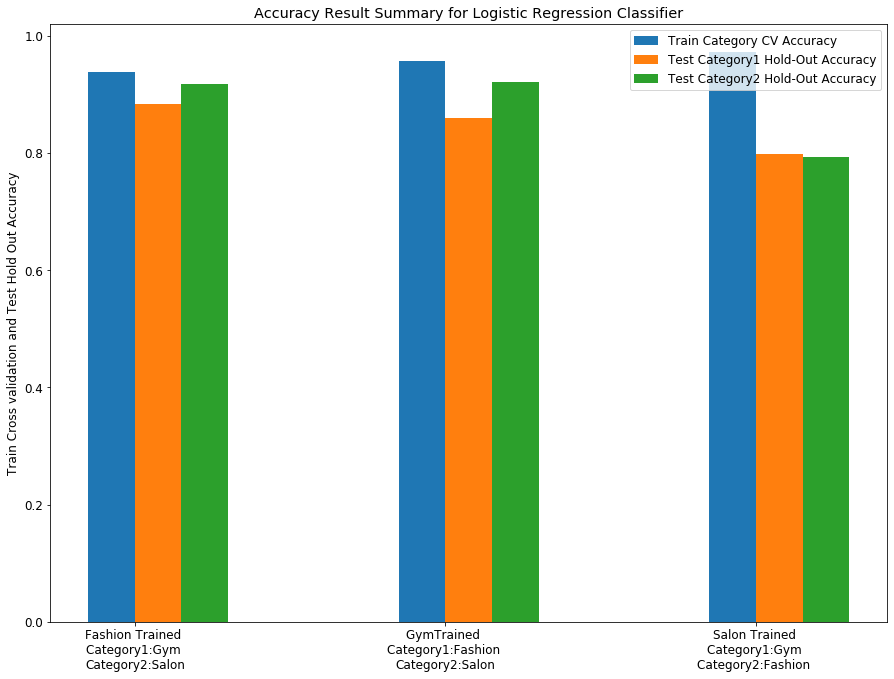

In [33]:
index=['Fashion Trained \nCategory1:Gym \nCategory2:Salon','GymTrained \nCategory1:Fashion \nCategory2:Salon','Salon Trained \nCategory1:Gym \nCategory2:Fashion ']
print("Cross Validation Results on train data for each category: ",train_acc_pred)
print("Cross Validation Results on test data for each category: ",test_acc1_pred)
print("Cross Validation Results on test data for each category: ",test_acc2_pred)
ix=np.array([1,2,3])
fig, ax = plt.subplots(figsize=(15,11))
bar_width = 0.15
ax.bar(ix,train_acc_pred, label='Train Category CV Accuracy',width=bar_width)
ax.bar(ix+bar_width, test_acc1_pred, label='Test Category1 Hold-Out Accuracy',width=bar_width)
ax.bar(ix+bar_width+bar_width, test_acc2_pred, label='Test Category2 Hold-Out Accuracy',width=bar_width)
ax.set_xticklabels(index)
ax.set_xticks(ix+bar_width/2)
ax.set_title('Accuracy Result Summary for Logistic Regression Classifier')
ax.set_ylabel('Train Cross validation and Test Hold Out Accuracy')
ax.legend()
plt.show()

### <b> <font color='red'> <i>NOTE:</i> The performance we get in these cases is not directly comparable as we are training the models with the entire dataset of 1 one category and we are not able to test the model with the same data as none is left. However, we are using 4-Fold cross validation here to evaluate the models performance on the training data but this is not the best approach for this comparision, as we are comparing it with the models accuracy obtained by hold-out testing </font> </b>

- ###  Evaluation of LR model trained on Fashion datset and tested on Gym and Salon datasets.
> In Gym dataset there were actually 35% Negative reviews and predicted Negative reviews are 27% and number of Negative reviews in Salon is 22% and predicted were 18%. For both the dataset model shows slight bias towards Majority Class. i.e. Positive Class.
The model trained on Faishon dataset seems to be performing good when tested on Salon dataset as compared to that when tested on Gym dataset. Accuracy calculated from hold-out testing on the Salon dataset is 91% where as that on gym dataset is 88%. Also, the precision score is high for Salon dataset by very small margin. Overall, performance on the Salon dataset is better as the number of false positives is also less as compared to Gym dataset.

- ###  Evaluation of LR model trained on Gym datset and tested on Fashion and Salon datasets.
> In Fashion dataset there were actually 40% Negative reviews and predicted Negative reviews are 36% and number of Negative reviews in Salon is 22% and predicted were 23%. For Fashion dataset model shows slight bias towards Majority Class. i.e. Positive Class. However, for the Salon dataset the nodel doen't show any bias.
Again, the model trained on Gym dataset seems to be performing good when tested on Salon dataset as compared to that when tested on fashion dataset. Accuracy calculated from hold-out testing on the Salon dataset is 92% where as that on gym dataset is 86%. Also, the precision score is high for Salon dataset. Thus, performance on the Salon dataset is again better here also as the number of false positives is very less as compared to Gym dataset. For salon only 3.50 % predictions are FP whereas for the Gym dataset approx. 9% of the predictions are FPs.

- ###  Evaluation of LR model trained on Salon datset and tested on Fashion and Gym datasets.
> In Gym dataset there were actually 35% Negative reviews and predicted Negative reviews are 16% and number of Negative reviews in Fashion is 40% and predicted were 21%. For both the dataset model high bias towards Positive Class.
Again, the model trained on Salon dataset seems to have approximately similar performance on Fashion as well as Salon dataset. Accuracy calculated from hold-out testing on both Gym and Fashion dataset is around 79% . For, both the dataset False positive is high, somewhat around 20%. Thus, the model trained with Salon data seems to be overfitted as on the training data models accuracy is 97% but on the the test data accuracy is quite less.


# <font color='green'> CONCLUSION:</font>
(NOTE: Detailed conclusion already discussed at the end of each section)

> 1. In section 1, we pre-process the data by cleaning and preparing it for the further text classification. Properly cleaned and processed data helps to improve the performance of the classifier and speed up the classification process, therby aiding sentiment analysis. We have used standard NLTks text mining techniques like tokenisation, stop words filtering, lemmatisation with POS Tagging, we could also use default Scikit-Learn's text processing functionalities provided with transformers like CountVectoriser of TF-IDF vectoriser, both the techniques have almost similar impact on the performance of the classifiers.
For instance, in section three we have used only 1500 features and words with minimum frequency 5(max_features=1500, min_df=5), using all the features results in a very slight drop in accuracy of the models. Concludingly, <b>properly pre-processed text and appropriate feature selection strategies do impact the performance of the model</b>.

> 2. In section 2, trained and tested all the three models on Fashion category to see evaluate the best performing model. Random Forest, uses multiple decision trees and generally it is beleieved that ensembles perform better than individual model. Though the performance of the Random forest model was not bad at all, but after evaluating all the metrics, I concluded logistic regression outperformed random Forest and Naive Bayes due to Hig Accuracy, High AUC Score and least False Positives. This is contrary to what I was expecting. However,<b> in this case of binary classification and relatively small dataset these results can be justified. As per my understanding, Logistic regression does a better job of classification for this task. </b>

> 3. Also, after evaluating all the metrics in Section two (High Models Accuracy from Hold-Out Testing, Low Number of False Positives and therefore high precision), we can say that when LR model was trained and tested on the individual category, it performed good for the Salon Category (high TPs, low FPs and FNs). However, when the model trained on Salon category and was tested on the other two datsets, the model did not perform very well. Same is displayed on the Accuracy result Summary Graph. We could say very slight overfitting was observed also the number of false positive was also very high around 390 for the model trained with Salon category.<b> And, as discusssed for such business we would like to keep false reviews as low as possible. Overall, we can say that for our model accuracy wise and precision wise, models trained with Gym or Fashion dataset tend to perform better, whereas the performance with the Salon dataset is comparatively poor keeping in mind all the above discussed evaluation metrics.</b>